In [2]:
import torch, os, cv2, re
import scipy.io as sio
import numpy as np
import pandas as pd
import seaborn as sns
 
from PIL import Image, ImageDraw, ImageFont

import sys
sys.path.append('/home/jinhanz/cs/concreteness')  # Replace with the actual path to the parent directory
from other.utils import draw_highlighted_caption, linreg_scatter

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

stimuli_root = "/opt/jinhanz/results/2509_concreteness/stimuli/"
results_root = "/opt/jinhanz/results/2509_concreteness/results/"

[nltk_data] Downloading package punkt to /home/jinhanz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/jinhanz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jinhanz/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [4]:
import json, random, csv, time, os, random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import statsmodels.formula.api as smf
from datetime import datetime
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt
from collections import defaultdict
import torchvision.transforms as T

# Load data
with open("../../data/coco_caption_concereteness_with_lemmatization.json") as f:
    data = json.load(f)

for i, img in enumerate(data):
    max_score, min_score = 0, 100
    max_id, min_id = 0, 0
    for c, cap in enumerate(img['caption_concreteness']):
        mean_score = mean(cap['concreteness'])
        data[i]['caption_concreteness'][c]['concrete_score'] = mean_score
        data[i]['caption_concreteness'][c]['abstract_score'] = mean_score
        if mean_score > max_score:
            max_score = mean_score
            max_id = cap['id']
        if mean_score < min_score:
            min_score = mean_score
            min_id = cap['id']
    data[i]['concrete_abstact_diff'] = {
        'value' : max_score - min_score,
        'ids': [max_id, min_id],
}

all_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var", "abstract_score", "concrete_score"]
test_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var"]

# Filter entries with both concrete and abstract ids
filtered_data = [item for item in data if len(set(item['concrete_abstact_diff']['ids'])) > 1]
filtered_data = sorted(filtered_data, key=lambda x: x['concrete_abstact_diff']['value'], reverse=True)

def extract_attr_lists(data_subset):
    ids = []
    abs_captions = []
    con_captions = []
    value_diffs = []
    abs_vals = {attr: [] for attr in all_attributes}
    con_vals = {attr: [] for attr in all_attributes}

    for entry in data_subset:
        ids.append(entry['image'])
        value_diffs.append(entry['concrete_abstact_diff']['value'])
        con_id, abs_id = entry['concrete_abstact_diff']['ids']
        con_cap = next(c for c in entry['caption_concreteness'] if c['id'] == con_id)
        abs_cap = next(c for c in entry['caption_concreteness'] if c['id'] == abs_id)

        abs_captions.append(abs_cap)
        con_captions.append(con_cap)

        for attr in ["concrete_score", "abstract_score"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        if 'char_number' in all_attributes:
            abs_vals['char_number'].append(len(abs_cap['caption']))
            con_vals['char_number'].append(len(con_cap['caption']))

        if 'word_number' in all_attributes:
            abs_vals['word_number'].append(len(abs_cap['caption'].split(' ')))
            con_vals['word_number'].append(len(con_cap['caption'].split(' ')))

        for attr in ["matching_score", "emap_var"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        for attr in ["word_importances", "word_frequency"]:
            if attr in all_attributes:
                abs_vals[attr].append(mean(abs_cap[attr]))
                con_vals[attr].append(mean(con_cap[attr]))

    return ids, value_diffs, abs_captions, con_captions, abs_vals, con_vals

ids_all, value_diffs_all, _, _, abs_vals_all, con_vals_all = extract_attr_lists(filtered_data)

experiment = '20250723_193742'

selected_indices = []
saved = pd.read_csv(f"{stimuli_root}/250602-250723_stimuli_average/{experiment}/captions_and_attributes.csv")
saved_ids = saved['image_id'].tolist()
for e, entry in enumerate(filtered_data):
    if entry['image'] in saved_ids:
        selected_indices.append(e)

selected_indices.sort()
selected_entries = [filtered_data[idx] for idx in selected_indices]

ids_selected, value_diffs_selected, abs_captions_selected, con_captions_selected, abs_vals_selected, con_vals_selected = extract_attr_lists(selected_entries)

In [5]:
analysis_name = "251215_cogsci_60"
data_all = pd.DataFrame()

### Word Importance Vector Generation

In [6]:
def normalized_ranking(raw_importance):
    ranks = np.argsort(np.argsort(raw_importance)) + 1  # +1 to make ranks start from 1
    normalized_ranks = ranks / sum(ranks)
    # normalized_ranks = (ranks - ranks.min()) / (ranks.max() - ranks.min())
    return normalized_ranks

In [7]:
for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected, abs_captions_selected, con_captions_selected)):
    # Load image
    img_path = f"{results_root}/{analysis_name}/human/image/images/matched_abs_{image_id.split('/')[-1]}"

    abs_emap = torch.load(f"../../data/emaps_resized/{image_id.split('_')[-1].split('.')[0]}_{abs_cap['id']}.pt", map_location="cpu")
    con_emap = torch.load(f"../../data/emaps_resized/{image_id.split('_')[-1].split('.')[0]}_{con_cap['id']}.pt", map_location="cpu")

    img = Image.open(img_path).convert("RGB")
    h, w = img.size
    resize = T.Resize((w,h))

    emaps =resize(torch.stack([abs_emap, con_emap], dim=0))

    abs_emap = emaps[0].numpy()
    con_emap = emaps[1].numpy()

    for con, cap, map in zip(['abs', 'con'], [abs_cap, con_cap], [abs_emap, con_emap]):
        human_map = torch.load(f"{results_root}/{analysis_name}/human/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        image_grp1_map = torch.load(f"{results_root}/{analysis_name}/emhmm/image/grp1/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        image_grp2_map = torch.load(f"{results_root}/{analysis_name}/emhmm/image/grp2/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        # whole_screen_grp1_map = torch.load(f"{results_root}/{analysis_name}/emhmm/whole_screen/grp1/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        # whole_screen_grp2_map = torch.load(f"{results_root}/{analysis_name}/emhmm/whole_screen/grp2/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()

        data_all = pd.concat([data_all, pd.DataFrame([{
            "condition": con,
            "image_id": image_id,
            "caption": cap['caption'],
            "caption_words": [re.sub(r'[^\w\s]', '', tok) for tok in cap['caption'].split()],
            "concreteness": cap["concreteness"],
            "concrete_score": mean(cap['concreteness']),
            "target_words": cap["words"],
            "clip_map": map,
            "clip_word_importance": cap['word_importances'],
            "clip_word_rank": normalized_ranking(cap['word_importances']),
            "human_map": human_map,
            "human_word_importance": None,
            "human_word_rank": None,
            "image_grp1_map": image_grp1_map,
            "image_grp2_map": image_grp2_map,
            "image_grp1_word_importance": None,
            "image_grp2_word_importance": None,
            "image_grp1_word_rank": None,
            "image_grp2_word_rank": None,
            # "caption_grp1_word_importance": None,
            # "caption_grp2_word_importance": None,
            # "caption_grp1_word_rank": None,
            # "caption_grp2_word_rank": None,
            # "whole_screen_grp1_map": whole_screen_grp1_map,
            # "whole_screen_grp2_map": whole_screen_grp2_map,
            # "whole_screen_grp1_word_importance": None,
            # "whole_screen_grp2_word_importance": None,
            # "whole_screen_grp1_word_rank": None,
            # "whole_screen_grp2_word_rank": None,
        }], index=[f"matched_{con}_{image_id.split('/')[-1]}"])], ignore_index=False)

In [8]:
import ast 

image_info_segmentation = pd.read_csv(f"{stimuli_root}/250619-250723_stimuli_experiment/20250723_193742/image_info_segmentation.csv")

for _, row in image_info_segmentation.iterrows():
    trial_id = row['trial_id']

    if "mismatched" in trial_id:
        continue  

    word_spans = ast.literal_eval(row['word_spans'])

    for group in ['human', 'image_grp1', 'image_grp2']:
                    # 'caption_grp1', 'caption_grp2',
                    # 'whole_screen_grp1', 'whole_screen_grp2']:

        if 'grp' in group:
            fixations = pd.read_excel(f"{results_root}/{analysis_name}/emhmm/{group[:-5]}/{group[-4:]}/whole_screen/fixations/{trial_id}.xlsx")
        else:
            fixations = pd.read_excel(f"{results_root}/{analysis_name}/{group}/whole_screen/fixations/{trial_id}.xlsx")

        num_fixations = []

        for span in word_spans:
            x1, x2, y1, y2 = span

            # Filter fixations within the bounding box
            y1 = 1024 - y1
            y2 = 1024 - y2
            y1, y2 = y2, y1

            num_fixs = np.sum((fixations['CURRENT_FIX_X'] >= x1) & (fixations['CURRENT_FIX_X'] <= x2) &
                            (fixations['CURRENT_FIX_Y'] >= y1) & (fixations['CURRENT_FIX_Y'] <= y2))
            
            num_fixations.append(num_fixs)

        # Min-max normalization for num_fixations
        data_all.at[trial_id, f'{group}_word_importance'] = (np.array(num_fixations) - np.min(num_fixations)) / (np.max(num_fixations) - np.min(num_fixations))
        data_all.at[trial_id, f'{group}_word_rank'] = normalized_ranking(np.array(num_fixations))

### Visualize Word Importance

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager

for group in ['human']:

    for measure in ['importance']:

        output_dir = f'{results_root}/{analysis_name}/{group}/caption/word_{measure}_uncolored'
        os.makedirs(output_dir, exist_ok=True)

        for trial_id, info in data_all.iterrows():
            # Abstract caption
            caption_attention = info[f'{group}_word_{measure}']
            draw_highlighted_caption(info['caption'],
                                    info['target_words'],
                                    info['concreteness'],
                                    caption_attention if measure == 'importance' else (np.array(caption_attention) - np.min(caption_attention)) / (np.max(caption_attention) - np.min(caption_attention)),
                                save_path=os.path.join(output_dir, trial_id+".png"),
                                concreteness_coloring=False)

raw importance highlight without concreteness coloring

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager

output_dir = f'{results_root}/clip/caption_importance_uncolored'
os.makedirs(output_dir, exist_ok=True)

for trial_id, info in data_all.iterrows():
    caption_attention = info["clip_word_importance"]
    draw_highlighted_caption(info['caption'],
                            info['target_words'],
                            info['concreteness'],
                            caption_attention,
                        save_path=os.path.join(output_dir, trial_id+".png"),
                        importance_coloring=False)

### Calculate PCC (Alignment Scores)

In [9]:
for trial_id, info in data_all.iterrows():
    for group in ['human', 'image_grp1', 'image_grp2']:
        data_all.at[trial_id, f'{group}_map_pcc'] = np.corrcoef(info['clip_map'].flatten(), info[f'{group}_map'].flatten())[0, 1]
    for group in ['human', 'image_grp1', 'image_grp2']:
        data_all.at[trial_id, f'{group}_word_importance_pcc'] = np.corrcoef(info['clip_word_importance'], info[f'{group}_word_importance'])[0, 1]
        data_all.at[trial_id, f'{group}_word_rank_pcc'] = np.corrcoef(info['clip_word_rank'], info[f'{group}_word_rank'])[0, 1]
    for group in ['human', 'image_grp1', 'image_grp2']: 
        data_all.at[trial_id, f'{group}_importance_concatenate_pcc'] = np.corrcoef(
            np.concatenate([info['clip_map'].flatten(), info['clip_word_importance']]),
            np.concatenate([info[f'{group}_map'].flatten(), info[f'{group}_word_importance']])
        )[0, 1]

        data_all.at[trial_id, f'{group}_rank_concatenate_pcc'] = np.corrcoef(
            np.concatenate([info['clip_map'].flatten(), info['clip_word_rank']]),
            np.concatenate([info[f'{group}_map'].flatten(), info[f'{group}_word_rank']])
        )[0, 1]

## Statistical Analysis

### Bias: Concreteness vs Word-Importance Correlation

In [10]:
all_words_df = pd.DataFrame(columns=[
                "trial_id",
                "image_id",
                "word_index",
                "word",
                "pos_tag",
                "condition",
                "concreteness",
                "clip_importance",
                "human_importance",
                "clip_rank",
                "human_rank",
                "image_grp1_importance",
                "image_grp2_importance",
                "image_grp1_rank",
                "image_grp2_rank",
            ])

for trial_id, info in data_all.iterrows():
    pos_tags = nltk.pos_tag(info['caption_words'])
    for w_idx, (word, tag) in enumerate(pos_tags):
        all_words_df = pd.concat([
            all_words_df,
            pd.DataFrame([{
                "trial_id": trial_id,
                "image_id": info["image_id"],
                "word_index": w_idx,
                "word": word,
                "pos_tag": tag,
                "condition": info['condition'],
                "concreteness": info['concreteness'][info['target_words'].index(wnl.lemmatize(word))] if wnl.lemmatize(word) in info['target_words'] else None,
                "clip_importance": info['clip_word_importance'][w_idx],
                "human_importance": info['human_word_importance'][w_idx],
                "clip_rank": info['clip_word_rank'][w_idx],
                "human_rank": info['human_word_rank'][w_idx],
                "image_grp1_importance": info['image_grp1_word_importance'][w_idx],
                "image_grp2_importance": info['image_grp2_word_importance'][w_idx],
                "image_grp1_rank": info['image_grp1_word_rank'][w_idx],
                "image_grp2_rank": info['image_grp2_word_rank'][w_idx],
            }])
        ], ignore_index=True)

all_words_df.to_csv(f"./data/all_words_df.csv", index=False)

/tmp/ipykernel_1677660/3002240268.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_words_df = pd.concat([


#### Regression (Sepearte agent)

Slope: 0.1678, Intercept: -0.2972, R^2: 0.2344, p-value: 2.9662e-60


/tmp/ipykernel_2803228/3647360566.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=plot_data, x=x_attr, y=y_attr, hue=condition_attr, palette={'con': 'tab:blue', 'abs': 'tab:orange'}, alpha=0.7, edgecolor='k')


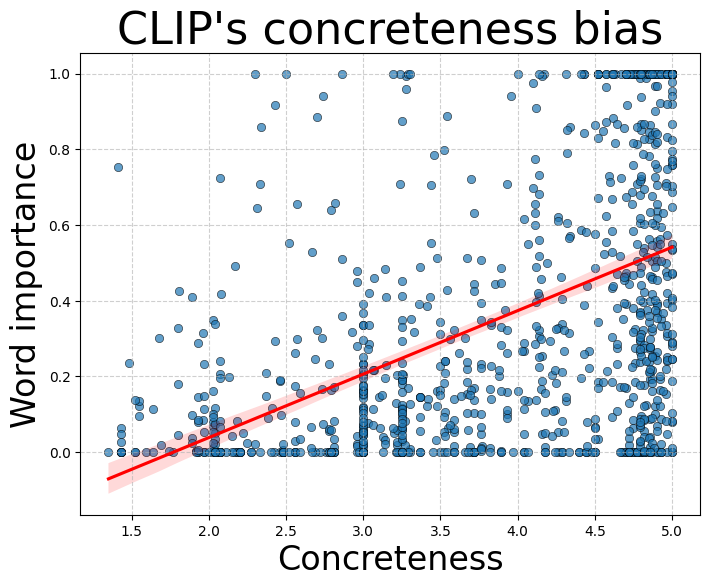

Slope: 0.0230, Intercept: 0.4947, R^2: 0.0063, p-value: 1.1961e-02


/tmp/ipykernel_2803228/3647360566.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=plot_data, x=x_attr, y=y_attr, hue=condition_attr, palette={'con': 'tab:blue', 'abs': 'tab:orange'}, alpha=0.7, edgecolor='k')


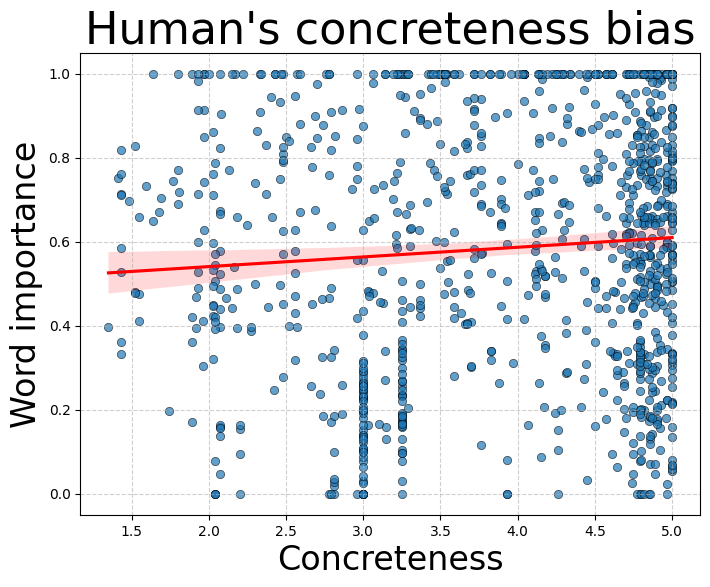

In [ ]:
for grp in ['clip','human']:
    plot_data = all_words_df[all_words_df['concreteness'].notna()]
    linreg_scatter(plot_data,
                 x_attr='concreteness',
                 y_attr=f'{grp}_importance',
                #  condition_attr='condition',
                 title=f"{grp}'s concreteness bias".replace("clip","CLIP").replace("human","Human"),
                 xlabel='Concreteness',
                 ylabel=f'Word Importance',
                 save_path=None)

#### Mixed-effect (CLIP vs Human)

In [ ]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for _, info in all_words_df.iterrows():
    if np.isnan(info['concreteness']) or not (info['pos_tag'].startswith('VB') or info['pos_tag'].startswith('NN')):
        continue
    for agent in ['clip','human']:
        long_format_data = pd.concat([
            long_format_data,
            pd.DataFrame([{
                "trial_id": info["trial_id"],
                "image_id": info["image_id"],
                "condition": info["condition"],
                "POS": 'VB' if info['pos_tag'].startswith('VB') else 'NN',
                "concreteness": info["concreteness"],
                "importance": info[f"{agent}_importance"],
                "rank": info[f"{agent}_rank"],
                "agent": agent,
            }])
        ], ignore_index=True)

long_format_data['agent'] = long_format_data['agent'].astype('category')
long_format_data['agent'] = pd.Categorical(long_format_data['agent'], categories=['human','clip'], ordered=False)

for measurement in ['importance', 'rank']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    long_format_data.to_csv(f"./data/concreteness_{measurement}.csv", index=False)
    model = smf.mixedlm(f"{measurement} ~ concreteness * agent", long_format_data, groups=long_format_data["image_id"])
    result = model.fit(method="powell")
    print(result.summary())

Mixed-Effect Model Analysis for importance:


/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     importance
No. Observations:       1342        Method:                 REML      
No. Groups:             80          Scale:                  0.1002    
Min. group size:        10          Log-Likelihood:         -372.0822 
Max. group size:        26          Converged:              Yes       
Mean group size:        16.8                                          
----------------------------------------------------------------------
                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                   0.836    0.072  11.619 0.000  0.695  0.977
model[T.clip]              -1.159    0.102 -11.394 0.000 -1.358 -0.960
concreteness               -0.048    0.016  -2.978 0.003 -0.080 -0.016
concreteness:model[T.clip]  0.225    0.023   9.848 0.000  0.181  0.270
Group Var              

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### Mixed effect (EMHMM image_grp1 vs image_grp2)

In [18]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for _, info in all_words_df.iterrows():
    if np.isnan(info['concreteness']) or not (info['pos_tag'].startswith('VB') or info['pos_tag'].startswith('NN')):
        continue
    for model in ['image_grp1','image_grp2']:
        long_format_data = pd.concat([
            long_format_data,
            pd.DataFrame([{
                "trial_id": info["trial_id"],
                "image_id": info["image_id"],
                "condition": info["condition"],
                "POS": 'VB' if info['pos_tag'].startswith('VB') else 'NN',
                "concreteness": info["concreteness"],
                "importance": info[f"{model}_importance"],
                "rank": info[f"{model}_rank"],
                "group": model,
            }])
        ], ignore_index=True)

long_format_data['group'] = pd.Categorical(long_format_data['group'], categories=['image_grp2','image_grp1'], ordered=False)

for measurement in ['importance', 'rank']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    model = smf.mixedlm(f"{measurement} ~ concreteness * group", long_format_data, groups="image_id")
    result = model.fit(method="powell")
    print(result.summary())

Mixed-Effect Model Analysis for importance:


/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                   Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       importance
No. Observations:        1342          Method:                   REML      
No. Groups:              80            Scale:                    0.0828    
Min. group size:         10            Log-Likelihood:           -251.6021 
Max. group size:         26            Converged:                Yes       
Mean group size:         16.8                                              
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         0.779    0.066 11.870 0.000  0.651  0.908
group[T.image_grp1]               0.057    0.092  0.618 0.537 -0.124  0.238
concreteness                     -0.037    0.015 -2.512 0.012 -0.066 -0.008
concreteness:group[T.image_grp1

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


### Human-CLIP Alignment

In [10]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for trial_id, info in data_all.iterrows():
    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "trial_id": trial_id,
            "image_id": info["image_id"],
            "condition": info["condition"],
            "concreteness": info["concrete_score"],
            "map_pcc": info["human_map_pcc"],
            "word_importance_pcc": info["human_word_importance_pcc"],
            "importance_concatenate_pcc": info["human_importance_concatenate_pcc"],
            "word_rank_pcc": info["human_word_rank_pcc"],
            "rank_concatenate_pcc": info["human_rank_concatenate_pcc"]
        }])
    ], ignore_index=True)

import pandas as pd
import statsmodels.formula.api as smf

for measurement in ['map_pcc', 'word_importance_pcc', 'importance_concatenate_pcc', 'word_rank_pcc', 'rank_concatenate_pcc']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    long_format_data.to_csv(f"./data/alignment_{measurement}.csv", index=False)
    model = smf.mixedlm(f"{measurement} ~ condition", long_format_data, groups="image_id")
    result = model.fit()
    print(result.summary())

Mixed-Effect Model Analysis for map_pcc:
           Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   map_pcc
No. Observations:   160       Method:               REML   
No. Groups:         80        Scale:                0.0194 
Min. group size:    2         Log-Likelihood:       20.2980
Max. group size:    2         Converged:            Yes    
Mean group size:    2.0                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.283    0.027 10.610 0.000  0.231  0.336
condition[T.con] -0.003    0.022 -0.136 0.892 -0.046  0.040
image_id Var      0.038    0.077                           

Mixed-Effect Model Analysis for word_importance_pcc:


/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: word_importance_pcc
No. Observations: 160     Method:             REML               
No. Groups:       80      Scale:              0.0555             
Min. group size:  2       Log-Likelihood:     -12.2537           
Max. group size:  2       Converged:          Yes                
Mean group size:  2.0                                            
------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept           0.325     0.029  11.378  0.000   0.269   0.381
condition[T.con]    0.082     0.037   2.201  0.028   0.009   0.155
image_id Var        0.010     0.036                               

Mixed-Effect Model Analysis for importance_concatenate_pcc:
                 Mixed Linear Model Regression Results
Model:            MixedLM Dependen

In [13]:
for measurement in ['map_pcc', 'word_importance_pcc', 'importance_concatenate_pcc', 'word_rank_pcc', 'rank_concatenate_pcc']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    model = smf.mixedlm(f"{measurement} ~ concreteness", long_format_data, groups="image_id")
    result = model.fit()
    print(result.summary())

Mixed-Effect Model Analysis for map_pcc:
         Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: map_pcc
No. Observations:   160     Method:             REML   
No. Groups:         80      Scale:              0.0194 
Min. group size:    2       Log-Likelihood:     20.3139
Max. group size:    2       Converged:          Yes    
Mean group size:    2.0                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.300    0.091  3.311 0.001  0.122  0.477
concreteness -0.005    0.022 -0.208 0.836 -0.048  0.039
image_id Var  0.038    0.076                           

Mixed-Effect Model Analysis for word_importance_pcc:
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: word_importance_pcc
No. Observations: 160     Method:             REML               
No

### EMHMM - Image

##### Interpreting EMHMM (Variance)

In [9]:
import numpy as np

def heatmap_spatial_variance(heatmap, normalize_coords=True):
    H = np.asarray(heatmap, dtype=float)
    H = np.clip(H, 0, None)

    mass = H.sum()
    P = H / mass

    h, w = P.shape
    y, x = np.mgrid[0:h, 0:w]

    if normalize_coords:
        x = x / (w - 1)
        y = y / (h - 1)

    mu_x = (P * x).sum()
    mu_y = (P * y).sum()

    var = ((x - mu_x)**2 + (y - mu_y)**2) * P
    return var.sum()

def fixation_spatial_variance(
    trial_df,
    img_width=None,
    img_height=None,
    normalize_coords=True,
    x_col="CURRENT_FIX_X",
    y_col="CURRENT_FIX_Y",
    min_fixations=2,
):
    """
    Compute spatial variance of fixations for one trial.
    """

    # extract coordinates
    x = trial_df[x_col].to_numpy(dtype=float)
    y = trial_df[y_col].to_numpy(dtype=float)

    if len(x) < min_fixations:
        return np.nan

    # normalize coordinates if requested
    if normalize_coords:
        if img_width is None or img_height is None:
            raise ValueError("img_width and img_height required for normalization")
        x = x / img_width
        y = y / img_height

    # center of mass
    mu_x = x.mean()
    mu_y = y.mean()

    # spatial variance
    var = ((x - mu_x)**2 + (y - mu_y)**2).mean()
    return var

In [11]:
for trial_id, info in data_all.iterrows():
    
    # number of fixations on image; for confirming interpretations on EMHMM group
    # explorting strategy -> more fixations?
    for group in ['image_grp1', 'image_grp2']:
        heatmap = info[f'{group}_map']
        image_h, image_w = heatmap.shape
        fixations = pd.read_excel(f"{results_root}/{analysis_name}/emhmm/image/{group[-4:]}/image/fixations/{trial_id}.xlsx")
        data_all.at[trial_id, f'{group}_heatmap_var'] = heatmap_spatial_variance(heatmap)
        data_all.at[trial_id, f'{group}_fixation_var'] = fixation_spatial_variance(fixations, img_width=image_w, img_height=image_h)

for measurement in ['heatmap_var', 'fixation_var']:

    t_stat, p_value = ttest_rel(data_all[f'image_grp1_{measurement}'], data_all[f'image_grp2_{measurement}'])

    print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

(heatmap_var) T-statistic: 15.607898095293237, P-value: 6.775820550536285e-34
(fixation_var) T-statistic: 15.358120319649826, P-value: 3.18752330552084e-33


#### Alignment

In [ ]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for trial_id, info in data_all.iterrows():
    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "trial_id": trial_id,
            "image_id": info["image_id"],
            "condition": info["condition"],
            "group": "image_grp1",
            "map_pcc": info["image_grp1_map_pcc"],
        }, {
            "trial_id": trial_id,
            "image_id": info["image_id"],
            "condition": info["condition"],
            "group": "image_grp2",
            "map_pcc": info["image_grp2_map_pcc"],
        }])
    ], ignore_index=True)

long_format_data.to_csv(f"./data/alignment_image_groups_map_pcc.csv", index=False)

# Display the prepared long format DataFrame
import pandas as pd
import statsmodels.formula.api as smf

long_format_data['group'] = pd.Categorical(long_format_data['group'], categories=['image_grp1','image_grp2'], ordered=False)

for measurement in ['map_pcc']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    model = smf.mixedlm(f"{measurement} ~ group * condition", long_format_data, groups="image_id")
    result = model.fit()
    print(result.summary())

Mixed-Effect Model Analysis for map_pcc:
                     Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         map_pcc 
No. Observations:          320             Method:                     REML    
No. Groups:                80              Scale:                      0.0138  
Min. group size:           4               Log-Likelihood:             121.7153
Max. group size:           4               Converged:                  Yes     
Mean group size:           4.0                                                 
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             0.288    0.025 11.346 0.000  0.238  0.337
group[T.image_grp2]                  -0.060    0.019 -3.231 0.001 -0.096 -0.024
condition[T.con]    